# sklearn Mental Model — From Math to Systems

## Objective
This notebook builds a **clear mental model of scikit-learn** by explicitly
connecting:
- from-scratch linear regression (Week B)
- sklearn’s standardized execution workflow

The focus is **understanding**, not performance.

## What This Notebook Is (and Is Not)
✔ Explains how sklearn models learn and store state  
✔ Bridges math-first ML to system-first ML  
✘ No preprocessing  
✘ No pipelines  
✘ No train/test split (by design)

This isolation is intentional.


## Imports and Environment Setup

We keep dependencies minimal.
The goal is to reason about sklearn behavior, not tooling.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


## Dataset Creation (Controlled & Transparent)

We generate a simple synthetic dataset with a known relationship:

\[
y = 3x + 5 + \epsilon
\]

This allows:
- analytical verification of learned parameters
- clean comparison between sklearn and NumPy
- zero ambiguity about expected behavior


In [2]:
np.random.seed(42)

X = np.random.rand(100, 1) * 10
y = 3 * X.squeeze() + 5 + np.random.randn(100) * 1.0

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (100, 1)
y shape: (100,)


## Expected Data Shapes in scikit-learn

scikit-learn enforces **strict shape conventions**:

| Variable | Shape | Meaning |
|--------|------|---------|
| `X` | `(n_samples, n_features)` | Feature matrix |
| `y` | `(n_samples,)` | Target vector |

Even with a single feature, `X` **must remain 2D**.
This consistency enables:
- multi-feature extensibility
- pipelines
- automated validation

Shape discipline is a system-level design choice.


## Training Linear Regression (sklearn)

At this stage:
- No preprocessing
- No pipelines
- No evaluation logic

We focus solely on what `fit()` does to the model object.


In [3]:
model = LinearRegression()
model.fit(X, y)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## What Happens During `fit()`

Calling `fit(X, y)` causes the estimator to:
1. Solve the regression optimization problem
2. Learn optimal parameters
3. Store them **inside the object**

These parameters persist as object attributes and define the model’s state.


In [4]:
print("Coefficient (slope):", model.coef_)
print("Intercept (bias):", model.intercept_)


Coefficient (slope): [2.95402268]
Intercept (bias): 5.215096157546753


## Parameter Interpretation

Given the data-generating process:
\[
y = 3x + 5 + noise
\]

We expect:
- `coef_ ≈ 3`
- `intercept_ ≈ 5`

Small deviations arise due to:
- random noise
- floating-point arithmetic


## Prediction Phase

Once fitted:
- `predict()` uses stored parameters
- no learning occurs
- internal state remains unchanged


In [5]:
X_sample = X[:5]
preds = model.predict(X_sample)

print("Inputs:", X_sample.squeeze())
print("Predictions:", preds)


Inputs: [3.74540119 9.50714306 7.31993942 5.98658484 1.5601864 ]
Predictions: [16.2790962  33.29941237 26.8383632  22.89960354  9.82392218]


## sklearn Models Are Stateful Objects

After `fit()`:
- learned parameters are stored internally
- attributes such as `coef_` and `intercept_` persist
- the object retains memory of training data patterns


In [6]:
print("coef_ exists:", hasattr(model, "coef_"))
print("intercept_ exists:", hasattr(model, "intercept_"))


coef_ exists: True
intercept_ exists: True


## Consistency of `predict()`

`predict()`:
- does not modify model state
- can be called repeatedly
- always produces identical outputs for identical inputs


In [7]:
preds_1 = model.predict(X_sample)
preds_2 = model.predict(X_sample)

print("Run 1:", preds_1)
print("Run 2:", preds_2)


Run 1: [16.2790962  33.29941237 26.8383632  22.89960354  9.82392218]
Run 2: [16.2790962  33.29941237 26.8383632  22.89960354  9.82392218]


## From-Scratch Linear Regression (Normal Equation)

To bridge with Week B, we compute linear regression manually using:

\[
\theta = (X^TX)^{-1}X^Ty
\]

This confirms sklearn executes **known mathematics**, not magic.


In [8]:
X_b = np.c_[np.ones((X.shape[0], 1)), X]
theta = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

w0_numpy = theta[0]
w1_numpy = theta[1]

print("NumPy intercept:", w0_numpy)
print("NumPy coefficient:", w1_numpy)


NumPy intercept: 5.215096157546754
NumPy coefficient: 2.954022677287697


## Computational Method: sklearn vs NumPy

- In this notebook, NumPy uses the **Normal Equation**  
  - Time complexity: \(O(d^3)\)
  - Can be numerically unstable for large or ill-conditioned matrices

- scikit-learn’s `LinearRegression` typically solves the problem using
  **Singular Value Decomposition (SVD)** via optimized LAPACK routines

Why this matters:
- SVD is more numerically stable
- Avoids explicit matrix inversion
- Scales better in real-world settings

This is why sklearn is preferred in production systems.


In [9]:
print("Sklearn intercept :", model.intercept_)
print("NumPy intercept   :", w0_numpy)

print("Sklearn coefficient:", model.coef_[0])
print("NumPy coefficient  :", w1_numpy)


Sklearn intercept : 5.215096157546753
NumPy intercept   : 5.215096157546754
Sklearn coefficient: 2.954022677287696
NumPy coefficient  : 2.954022677287697


## Visual Confirmation: Geometry of the Solution

We now visually compare:
- raw data
- sklearn regression line
- NumPy regression line

This provides geometric confirmation that:
- both methods converge to the same solution
- differences are purely numerical, not conceptual


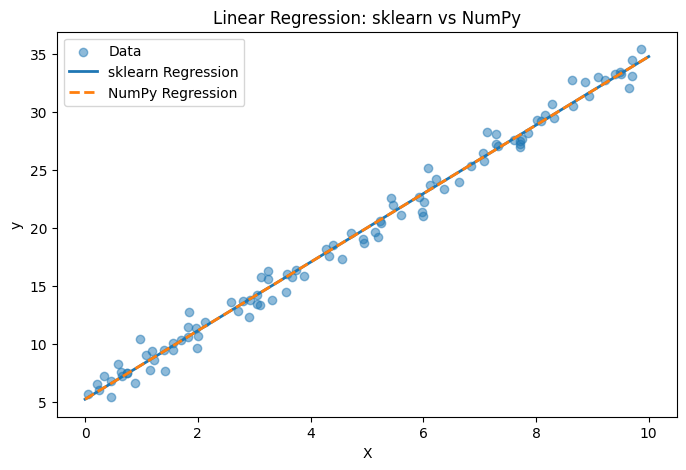

In [10]:
x_line = np.linspace(0, 10, 100).reshape(-1, 1)

y_sklearn = model.predict(x_line)
y_numpy = w1_numpy * x_line.squeeze() + w0_numpy

plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.5, label="Data")
plt.plot(x_line, y_sklearn, label="sklearn Regression", linewidth=2)
plt.plot(x_line, y_numpy, "--", label="NumPy Regression", linewidth=2)
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.title("Linear Regression: sklearn vs NumPy")
plt.show()


## Key Takeaways

- sklearn models are **stateful objects**
- `fit()` learns and stores parameters
- `predict()` reuses stored state without mutation
- sklearn uses numerically stable solvers (SVD)
- Uniform APIs enable system-level ML engineering

This mental model is foundational for:
- pipelines
- leakage prevention
- production ML workflows


## Stop Condition — Day 1

You should now be able to explain:
- what `fit()` does internally
- where learned parameters live
- why sklearn avoids explicit matrix inversion
- how geometry and math align across implementations

Only after this clarity do we proceed to:
**Day 2 — Data Splitting & Leakage**
